# Homework 1: TSMC (2330.TW) Stock Prediction
## LSTM + Attention Mechanism
---

In [1]:
# ============================================================
# 安裝 & 匯入所需套件
# ============================================================
!pip install yfinance scikit-learn tensorflow matplotlib -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Layer, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')

print("All packages imported successfully.")

All packages imported successfully.


In [2]:
# ============================================================
# 抓取 TSMC 股票資料 (近 10 年)
# ============================================================
ticker_symbol = '2330.TW'
end_date = datetime.now()
start_date = end_date - timedelta(days=10*365)

stock = yf.Ticker(ticker_symbol)
stock_df = stock.history(start=start_date.strftime('%Y-%m-%d'),
                         end=end_date.strftime('%Y-%m-%d'), interval='1d')
stock_df.index = stock_df.index.tz_localize(None)  # 移除時區
print(f"資料範圍: {stock_df.index[0].date()} ~ {stock_df.index[-1].date()}, 共 {len(stock_df)} 筆")
stock_df.tail()

資料範圍: 2016-04-08 ~ 2026-04-02, 共 2428 筆


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-27,1805.0,1825.0,1800.0,1820.0,28974140,0.0,0.0
2026-03-30,1780.0,1800.0,1780.0,1780.0,39889700,0.0,0.0
2026-03-31,1775.0,1790.0,1760.0,1760.0,49221091,0.0,0.0
2026-04-01,1840.0,1855.0,1830.0,1855.0,35537379,0.0,0.0
2026-04-02,1865.0,1865.0,1805.0,1810.0,25132417,0.0,0.0


In [3]:
# ============================================================
# 自定義 Attention Layer
# ============================================================
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        ui = K.tanh(K.dot(x, self.W) + self.b)
        uw = K.ones_like(ui[:, :, 0])
        uw = K.expand_dims(uw)
        alpha = K.softmax(K.sum(ui * uw, axis=2))
        alpha = K.expand_dims(alpha)
        context_vector = K.sum(x * alpha, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

print("Attention layer defined.")

Attention layer defined.


In [4]:
# ============================================================
# 工具函數
# ============================================================

def add_technical_indicators(df):
    """添加技術指標: MA5, MA20, RSI(14)"""
    data = df.copy()
    data['MA5'] = data['Close'].rolling(window=5).mean()
    data['MA20'] = data['Close'].rolling(window=20).mean()
    # RSI
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0.0).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data.dropna(inplace=True)
    return data

def create_dataset(dataset, look_back=1):
    """將時序資料轉換為監督式學習的 X, y"""
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back, 0])  # 預測 Close (第 0 個 feature)
    return np.array(dataX), np.array(dataY)

def mape(y_true, y_pred):
    """計算 MAPE"""
    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def build_model(look_back, n_features, lstm_units_1=128, lstm_units_2=64,
                dropout_rate=0.0, learning_rate=0.001):
    """建構 LSTM + Attention 模型"""
    model = Sequential()
    model.add(Input(shape=(look_back, n_features)))
    model.add(LSTM(units=lstm_units_1, return_sequences=True))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(LSTM(units=lstm_units_2, return_sequences=True))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Attention())
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error')
    return model

print("Utility functions defined.")

Utility functions defined.


---
# Phase 1: Model Tuning & Optimization (35%)

我們將針對以下超參數進行實驗：
1. **Sequence Length (look_back)**: 60, 90, 120
2. **Model Architecture (LSTM units)**: (64,32), (128,64), (256,128)
3. **Training Parameters**: Learning Rate (0.001, 0.0005), Batch Size (16, 32), Epochs (50, 100)
4. **Dropout**: 0.0, 0.2, 0.3
5. **Feature Selection**: Close only vs. Close + MA5 + MA20 + RSI

為節省時間，我們使用 grid 方式針對幾組有代表性的配置進行實驗。

In [5]:
# ============================================================
# Phase 1: 超參數調校實驗
# ============================================================

# 定義實驗配置: (name, look_back, units_1, units_2, lr, batch, epochs, dropout, use_features)
experiments = [
    # Baseline (原始設定)
    ('Baseline',          100, 128, 64, 0.001,  32, 50,  0.0,  False),
    # 1. 改 Sequence Length
    ('look_back=60',       60, 128, 64, 0.001,  32, 50,  0.0,  False),
    ('look_back=120',     120, 128, 64, 0.001,  32, 50,  0.0,  False),
    # 2. 改 Architecture
    ('units=64,32',       100,  64, 32, 0.001,  32, 50,  0.0,  False),
    ('units=256,128',     100, 256,128, 0.001,  32, 50,  0.0,  False),
    # 3. 改 Training Params
    ('lr=0.0005',         100, 128, 64, 0.0005, 32, 50,  0.0,  False),
    ('batch=16,epoch=100',100, 128, 64, 0.001,  16,100,  0.0,  False),
    # 4. 加 Dropout
    ('dropout=0.2',       100, 128, 64, 0.001,  32, 50,  0.2,  False),
    ('dropout=0.3',       100, 128, 64, 0.001,  32, 50,  0.3,  False),
    # 5. 加技術指標 (Feature Selection)
    ('features+MA+RSI',   100, 128, 64, 0.001,  32, 50,  0.0,  True),
    # 6. 綜合最佳嘗試
    ('Best Combo',         60, 128, 64, 0.0005, 16,100,  0.2,  True),
]

results = []

for name, lb, u1, u2, lr, bs, ep, dr, use_feat in experiments:
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"  look_back={lb}, units=({u1},{u2}), lr={lr}, batch={bs}, epochs={ep}, dropout={dr}, features={use_feat}")
    print(f"{'='*60}")

    # 準備資料
    if use_feat:
        data = add_technical_indicators(stock_df)
        features = data[['Close', 'MA5', 'MA20', 'RSI']].values
    else:
        data = stock_df.copy()
        features = data['Close'].values.reshape(-1, 1)

    n_features = features.shape[1]

    # 正規化
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(features)

    # 建立 Close 的獨立 scaler (用於反轉預測值)
    close_scaler = MinMaxScaler(feature_range=(0, 1))
    close_scaler.fit_transform(data['Close'].values.reshape(-1, 1))

    # 建立資料集
    X, y = create_dataset(scaled, lb)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

    # 建立模型
    model = build_model(lb, n_features, u1, u2, dr, lr)

    # 訓練
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=ep, batch_size=bs, verbose=0, callbacks=[early_stop])

    # 預測
    train_pred = model.predict(X_train, verbose=0)
    test_pred = model.predict(X_test, verbose=0)

    # 反轉回原始尺度
    train_pred_inv = close_scaler.inverse_transform(train_pred)
    test_pred_inv = close_scaler.inverse_transform(test_pred)
    y_train_inv = close_scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_inv = close_scaler.inverse_transform(y_test.reshape(-1, 1))

    # 計算指標
    train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
    train_mape = mape(y_train_inv, train_pred_inv)
    test_mape = mape(y_test_inv, test_pred_inv)

    results.append({
        'Experiment': name,
        'look_back': lb,
        'Units': f'({u1},{u2})',
        'units_1': u1,
        'units_2': u2,
        'LR': lr,
        'Batch': bs,
        'Epochs': ep,
        'Dropout': dr,
        'use_features': use_feat,
        'Features': 'Close+MA+RSI' if use_feat else 'Close Only',
        'Train RMSE': round(train_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'Train MAPE(%)': round(train_mape, 2),
        'Test MAPE(%)': round(test_mape, 2)
    })
    print(f"  => Train RMSE={train_rmse:.2f}, Test RMSE={test_rmse:.2f}, "
          f"Train MAPE={train_mape:.2f}%, Test MAPE={test_mape:.2f}%")

print("\nAll experiments completed.")


Experiment: Baseline
  look_back=100, units=(128,64), lr=0.001, batch=32, epochs=50, dropout=0.0, features=False
  => Train RMSE=14.72, Test RMSE=49.09, Train MAPE=2.11%, Test MAPE=2.31%

Experiment: look_back=60
  look_back=60, units=(128,64), lr=0.001, batch=32, epochs=50, dropout=0.0, features=False
  => Train RMSE=15.23, Test RMSE=45.15, Train MAPE=2.40%, Test MAPE=2.24%

Experiment: look_back=120
  look_back=120, units=(128,64), lr=0.001, batch=32, epochs=50, dropout=0.0, features=False
  => Train RMSE=15.98, Test RMSE=49.52, Train MAPE=2.15%, Test MAPE=2.22%

Experiment: units=64,32
  look_back=100, units=(64,32), lr=0.001, batch=32, epochs=50, dropout=0.0, features=False
  => Train RMSE=26.62, Test RMSE=66.43, Train MAPE=5.88%, Test MAPE=3.29%

Experiment: units=256,128
  look_back=100, units=(256,128), lr=0.001, batch=32, epochs=50, dropout=0.0, features=False
  => Train RMSE=19.43, Test RMSE=60.71, Train MAPE=3.08%, Test MAPE=3.11%

Experiment: lr=0.0005
  look_back=100, unit

In [6]:
# ============================================================
# Phase 1: 結果統計表格
# ============================================================
results_df = pd.DataFrame(results)

# 顯示用的欄位（隱藏內部欄位）
display_cols = ['Experiment','look_back','Units','LR','Batch','Epochs',
                'Dropout','Features','Train RMSE','Test RMSE','Train MAPE(%)','Test MAPE(%)']
print("\n" + "="*100)
print("Phase 1: Hyperparameter Tuning Results")
print("="*100)
display(results_df[display_cols])

# 找出 Test RMSE 最低的配置，自動提取最佳參數
best_idx = results_df['Test RMSE'].idxmin()
best = results_df.iloc[best_idx]

best_params = {
    'look_back': int(best['look_back']),
    'lstm_units_1': int(best['units_1']),
    'lstm_units_2': int(best['units_2']),
    'learning_rate': float(best['LR']),
    'batch_size': int(best['Batch']),
    'epochs': int(best['Epochs']),
    'dropout_rate': float(best['Dropout']),
    'use_features': bool(best['use_features']),
}

print(f"\n*** Best Configuration: {best['Experiment']} ***")
print(f"    Test RMSE = {best['Test RMSE']}, Test MAPE = {best['Test MAPE(%)']}%")
print(f"\n自動提取的最佳參數 (將用於 Phase 2 & 3):")
for k, v in best_params.items():
    print(f"    {k} = {v}")


Phase 1: Hyperparameter Tuning Results


,Experiment,look_back,Units,LR,Batch,Epochs,Dropout,Features,Train RMSE,Test RMSE,Train MAPE(%),Test MAPE(%)
0,Baseline,100,"(128,64)",0.0010,32,50,0.0,Close Only,14.72,49.09,2.11,2.31
1,look_back=60,60,"(128,64)",0.0010,32,50,0.0,Close Only,15.23,45.15,2.40,2.24
2,look_back=120,120,"(128,64)",0.0010,32,50,0.0,Close Only,15.98,49.52,2.15,2.22
3,"units=64,32",100,"(64,32)",0.0010,32,50,0.0,Close Only,26.62,66.43,5.88,3.29
4,"units=256,128",100,"(256,128)",0.0010,32,50,0.0,Close Only,19.43,60.71,3.08,3.11
5,lr=0.0005,100,"(128,64)",0.0005,32,50,0.0,Close Only,15.45,47.65,2.37,2.20
6,"batch=16,epoch=100",100,"(128,64)",0.0010,16,100,0.0,Close Only,11.74,36.26,1.94,1.71
7,dropout=0.2,100,"(128,64)",0.0010,32,50,0.2,Close Only,59.48,184.00,8.67,10.53
8,dropout=0.3,100,"(128,64)",0.0010,32,50,0.3,Close Only,85.33,165.08,18.41,9.46
9,features+MA+RSI,100,"(128,64)",0.0010,32,50,0.0,Close+MA+RSI,19.34,51.97,3.62,2.46



*** Best Configuration: batch=16,epoch=100 ***
    Test RMSE = 36.26, Test MAPE = 1.71%

自動提取的最佳參數 (將用於 Phase 2 & 3):
    look_back = 100
    lstm_units_1 = 128
    lstm_units_2 = 64
    learning_rate = 0.001
    batch_size = 16
    epochs = 100
    dropout_rate = 0.0
    use_features = False


---
# Phase 2: Rolling Forecast Simulation (25%)

期間: **2026/3/12 ~ 2026/3/21**

每個交易日：
1. 使用該天之前的所有資料訓練模型
2. 預測該天的收盤價
3. 觀察實際收盤價後加入訓練集
4. 重複上述步驟

In [13]:
# ============================================================
# Phase 2: Rolling Forecast 函數
# ============================================================

def rolling_forecast(stock_df, start_date_str, end_date_str,
                     look_back=60, lstm_units_1=128, lstm_units_2=64,
                     dropout_rate=0.2, learning_rate=0.0005,
                     batch_size=16, epochs=100, use_features=True,
                     phase_name='Phase 2'):
    """
    Rolling Forecast: 每天用該天之前的所有歷史資料重新訓練，預測下一天收盤價。
    """
    start_dt = pd.Timestamp(start_date_str)
    end_dt = pd.Timestamp(end_date_str)

    # 取出目標區間的交易日
    all_dates = stock_df.index
    target_dates = all_dates[(all_dates >= start_dt) & (all_dates <= end_dt)]
    print(f"\n{phase_name} Rolling Forecast 目標交易日 ({len(target_dates)} 天):")
    for d in target_dates:
        print(f"  {d.date()}")

    predictions = []
    actuals = []
    dates_list = []

    for i, forecast_date in enumerate(target_dates):
        print(f"\n--- [{phase_name}] Day {i+1}/{len(target_dates)}: Forecasting {forecast_date.date()} ---")

        # 取 forecast_date 之前的所有資料作為訓練資料
        train_data = stock_df[stock_df.index < forecast_date].copy()

        if use_features:
            train_data = add_technical_indicators(train_data)
            features_cols = ['Close', 'MA5', 'MA20', 'RSI']
        else:
            features_cols = ['Close']

        feature_values = train_data[features_cols].values
        n_features = feature_values.shape[1]

        # 正規化
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled = scaler.fit_transform(feature_values)

        close_scaler = MinMaxScaler(feature_range=(0, 1))
        close_scaler.fit_transform(train_data['Close'].values.reshape(-1, 1))

        # 建立訓練集
        X_all, y_all = create_dataset(scaled, look_back)

        # 建立並訓練模型
        model = build_model(look_back, n_features, lstm_units_1, lstm_units_2,
                            dropout_rate, learning_rate)
        early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
        model.fit(X_all, y_all, epochs=epochs, batch_size=batch_size,
                  verbose=0, callbacks=[early_stop])

        # 取最後 look_back 天做預測
        last_seq = scaled[-look_back:].reshape(1, look_back, n_features)
        pred_scaled = model.predict(last_seq, verbose=0)
        pred_price = close_scaler.inverse_transform(pred_scaled)[0][0]

        # 實際收盤價
        actual_price = stock_df.loc[forecast_date, 'Close']

        predictions.append(pred_price)
        actuals.append(actual_price)
        dates_list.append(forecast_date)

        print(f"   Predicted: {pred_price:.2f}, Actual: {actual_price:.2f}, "
              f"Error: {abs(pred_price - actual_price):.2f}")

        # 清理 Keras session 避免記憶體洩漏
        K.clear_session()

    # 計算整體指標
    rmse_val = np.sqrt(mean_squared_error(actuals, predictions))
    mape_val = mape(np.array(actuals), np.array(predictions))

    print(f"\n{'='*60}")
    print(f"{phase_name} Rolling Forecast 結果:")
    print(f"  RMSE = {rmse_val:.2f}")
    print(f"  MAPE = {mape_val:.2f}%")
    print(f"{'='*60}")

    return dates_list, predictions, actuals, rmse_val, mape_val

print("Rolling forecast function defined.")

Rolling forecast function defined.


In [14]:
# ============================================================
# Phase 2: 執行 Rolling Forecast (2026/3/12 ~ 2026/3/21)
# 使用 Phase 1 自動選出的最佳參數
# ============================================================
print("Phase 2 使用 Phase 1 最佳參數:")
for k, v in best_params.items():
    print(f"    {k} = {v}")

p2_dates, p2_preds, p2_actuals, p2_rmse, p2_mape = rolling_forecast(
    stock_df,
    start_date_str='2026-03-12',
    end_date_str='2026-03-25',
    **best_params,
    phase_name='Phase 2'
)

Phase 2 使用 Phase 1 最佳參數:
    look_back = 100
    lstm_units_1 = 128
    lstm_units_2 = 64
    learning_rate = 0.001
    batch_size = 16
    epochs = 100
    dropout_rate = 0.0
    use_features = False

Phase 2 Rolling Forecast 目標交易日 (10 天):
  2026-03-12
  2026-03-13
  2026-03-16
  2026-03-17
  2026-03-18
  2026-03-19
  2026-03-20
  2026-03-23
  2026-03-24
  2026-03-25

--- [Phase 2] Day 1/10: Forecasting 2026-03-12 ---
   Predicted: 1903.58, Actual: 1878.87, Error: 24.71

--- [Phase 2] Day 2/10: Forecasting 2026-03-13 ---
   Predicted: 1876.45, Actual: 1858.93, Error: 17.51

--- [Phase 2] Day 3/10: Forecasting 2026-03-16 ---
   Predicted: 1851.73, Actual: 1839.00, Error: 12.73

--- [Phase 2] Day 4/10: Forecasting 2026-03-17 ---
   Predicted: 1872.36, Actual: 1870.00, Error: 2.36

--- [Phase 2] Day 5/10: Forecasting 2026-03-18 ---
   Predicted: 1871.48, Actual: 1905.00, Error: 33.52

--- [Phase 2] Day 6/10: Forecasting 2026-03-19 ---
   Predicted: 1880.30, Actual: 1850.00, Error: 30.30


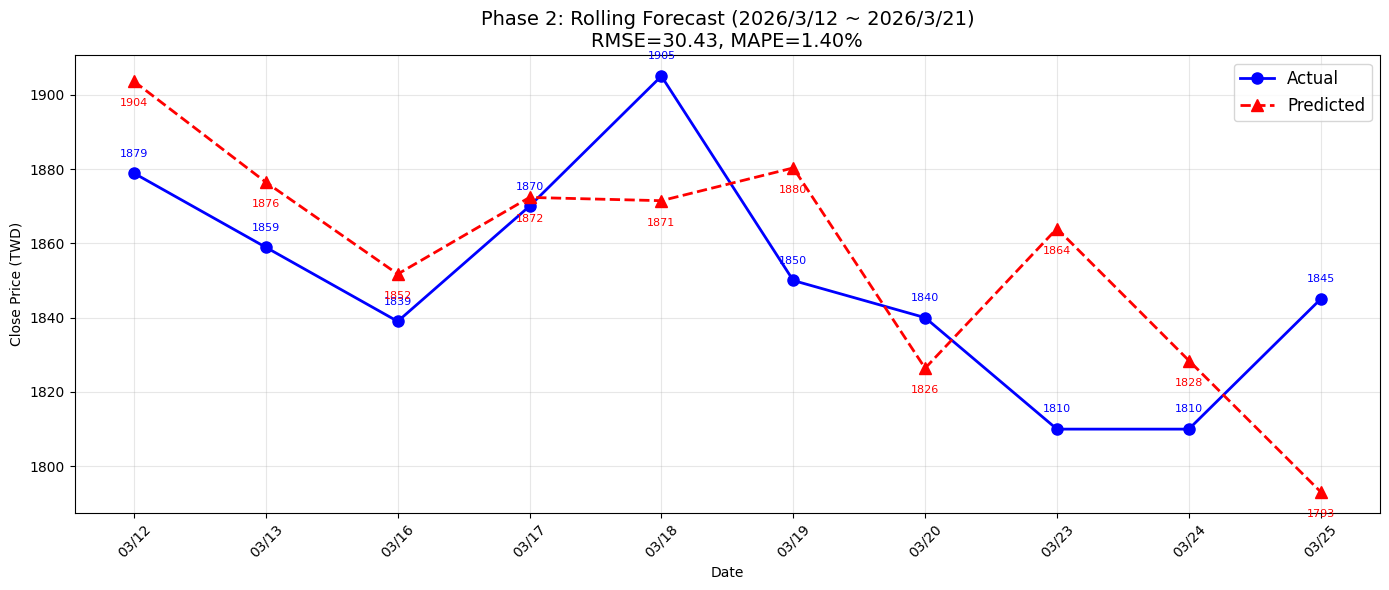

In [15]:
# ============================================================
# Phase 2: 繪製 Rolling Prediction vs. Actual 曲線圖
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
date_labels = [d.strftime('%m/%d') for d in p2_dates]

ax.plot(date_labels, p2_actuals, 'bo-', label='Actual', linewidth=2, markersize=8)
ax.plot(date_labels, p2_preds, 'r^--', label='Predicted', linewidth=2, markersize=8)

for i, (a, p) in enumerate(zip(p2_actuals, p2_preds)):
    ax.annotate(f'{a:.0f}', (date_labels[i], a), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8, color='blue')
    ax.annotate(f'{p:.0f}', (date_labels[i], p), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=8, color='red')

ax.set_title(f'Phase 2: Rolling Forecast (2026/3/12 ~ 2026/3/21)\nRMSE={p2_rmse:.2f}, MAPE={p2_mape:.2f}%',
             fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (TWD)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# Phase 3: Live Trading Competition (30%)

期間: **2026/3/20 ~ 2026/4/2** (10 個交易日)

使用與 Phase 2 相同的 Rolling Forecast 方法。

In [10]:
# ============================================================
# Phase 3: 執行 Rolling Forecast (2026/3/20 ~ 2026/4/2)
# 使用 Phase 1 自動選出的最佳參數
# ============================================================
print("Phase 3 使用 Phase 1 最佳參數:")
for k, v in best_params.items():
    print(f"    {k} = {v}")

p3_dates, p3_preds, p3_actuals, p3_rmse, p3_mape = rolling_forecast(
    stock_df,
    start_date_str='2026-03-20',
    end_date_str='2026-04-02',
    **best_params,
    phase_name='Phase 3'
)

Phase 3 使用 Phase 1 最佳參數:
    look_back = 100
    lstm_units_1 = 128
    lstm_units_2 = 64
    learning_rate = 0.001
    batch_size = 16
    epochs = 100
    dropout_rate = 0.0
    use_features = False

Phase 3 Rolling Forecast 目標交易日 (10 天):
  2026-03-20
  2026-03-23
  2026-03-24
  2026-03-25
  2026-03-26
  2026-03-27
  2026-03-30
  2026-03-31
  2026-04-01
  2026-04-02

--- [Phase 3] Day 1/10: Forecasting 2026-03-20 ---
   Predicted: 1883.80, Actual: 1840.00, Error: 43.80

--- [Phase 3] Day 2/10: Forecasting 2026-03-23 ---
   Predicted: 1937.52, Actual: 1810.00, Error: 127.52

--- [Phase 3] Day 3/10: Forecasting 2026-03-24 ---
   Predicted: 1832.57, Actual: 1810.00, Error: 22.57

--- [Phase 3] Day 4/10: Forecasting 2026-03-25 ---
   Predicted: 1817.87, Actual: 1845.00, Error: 27.13

--- [Phase 3] Day 5/10: Forecasting 2026-03-26 ---
   Predicted: 1828.91, Actual: 1840.00, Error: 11.09

--- [Phase 3] Day 6/10: Forecasting 2026-03-27 ---
   Predicted: 1812.45, Actual: 1820.00, Error: 7.55

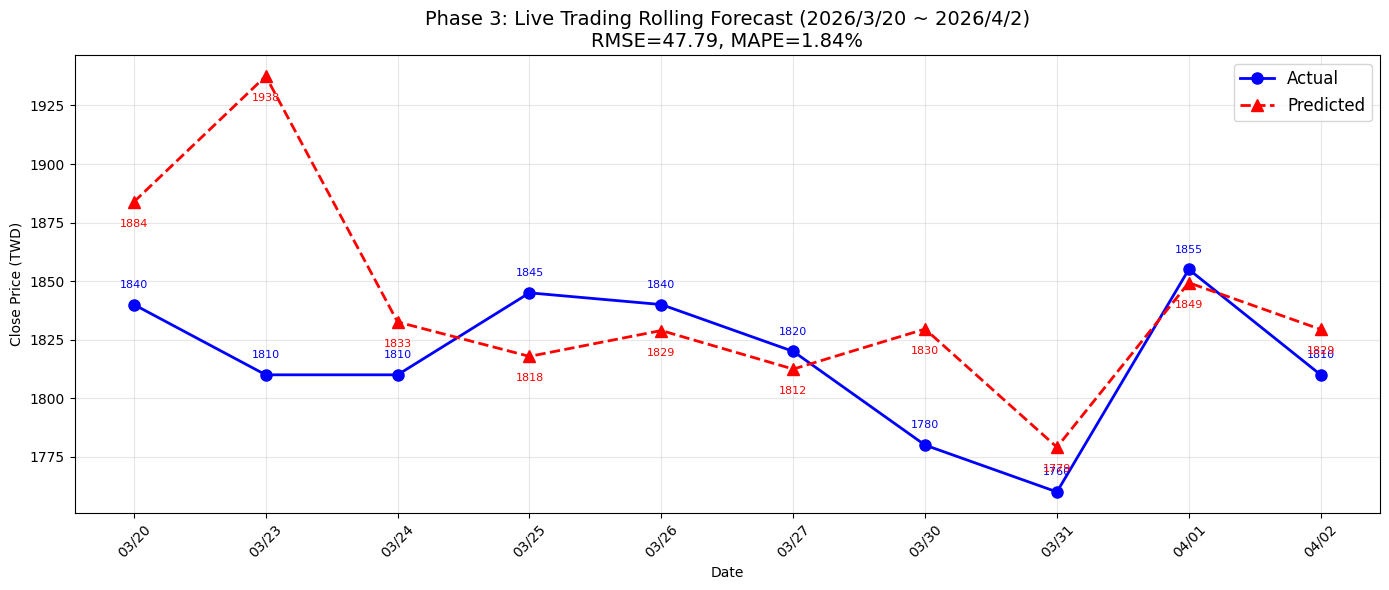

In [11]:
# ============================================================
# Phase 3: 繪製 Rolling Prediction vs. Actual 曲線圖
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
date_labels_3 = [d.strftime('%m/%d') for d in p3_dates]

ax.plot(date_labels_3, p3_actuals, 'bo-', label='Actual', linewidth=2, markersize=8)
ax.plot(date_labels_3, p3_preds, 'r^--', label='Predicted', linewidth=2, markersize=8)

for i, (a, p) in enumerate(zip(p3_actuals, p3_preds)):
    ax.annotate(f'{a:.0f}', (date_labels_3[i], a), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8, color='blue')
    ax.annotate(f'{p:.0f}', (date_labels_3[i], p), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=8, color='red')

ax.set_title(f'Phase 3: Live Trading Rolling Forecast (2026/3/20 ~ 2026/4/2)\nRMSE={p3_rmse:.2f}, MAPE={p3_mape:.2f}%',
             fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (TWD)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Phase 3: Trading Log 表格
# ============================================================
trading_log = pd.DataFrame({
    'Date': [d.strftime('%Y-%m-%d') for d in p3_dates],
    'Predicted Price': [round(p, 2) for p in p3_preds],
    'Actual Price': [round(a, 2) for a in p3_actuals],
    'Error': [round(abs(p - a), 2) for p, a in zip(p3_preds, p3_actuals)],
    'Error(%)': [round(abs(p - a) / a * 100, 2) for p, a in zip(p3_preds, p3_actuals)]
})
print("\nPhase 3 Trading Prediction Log:")
display(trading_log)
print(f"\nOverall RMSE: {p3_rmse:.2f}")
print(f"Overall MAPE: {p3_mape:.2f}%")


Phase 3 Trading Prediction Log:


,Date,Predicted Price,Actual Price,Error,Error(%)
0,2026-03-20,1883.800049,1840.0,43.80,2.38
1,2026-03-23,1937.520020,1810.0,127.52,7.05
2,2026-03-24,1832.569946,1810.0,22.57,1.25
3,2026-03-25,1817.869995,1845.0,27.13,1.47
4,2026-03-26,1828.910034,1840.0,11.09,0.60
5,2026-03-27,1812.449951,1820.0,7.55,0.42
6,2026-03-30,1829.550049,1780.0,49.55,2.78
7,2026-03-31,1779.099976,1760.0,19.10,1.09
8,2026-04-01,1849.310059,1855.0,5.69,0.31
9,2026-04-02,1829.400024,1810.0,19.40,1.07



Overall RMSE: 47.79
Overall MAPE: 1.84%
